In [1]:
import pandas as pd

# Load the 11-descriptor merged feature file
feat = pd.read_csv("../features/bbb_all_features_11desc.csv")

print("Feature matrix shape:", feat.shape)
feat.head()


Feature matrix shape: (538, 1134)


,ID,A,C,D,E,F,G,H,I,K,...,CHOC760101.lag3,BIGC670101.lag1,BIGC670101.lag2,BIGC670101.lag3,CHAM810101.lag1,CHAM810101.lag2,CHAM810101.lag3,DAYM780201.lag1,DAYM780201.lag2,DAYM780201.lag3
0,P_1,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.0,...,0.163399,0.933439,0.938734,0.280999,0.964580,1.636864,0.584594,0.809259,0.693818,0.913895
1,P_2,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,...,1.079102,1.007260,1.318813,1.007260,1.027014,1.279305,1.027014,1.531124,0.271084,1.531124
2,P_3,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,...,1.936292,1.404600,0.257148,1.775422,1.708487,0.353047,1.052744,1.266584,0.845771,0.265340
3,P_4,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.2,...,0.761516,1.624047,0.595490,0.856078,1.287744,0.757845,1.287744,1.722039,0.727748,0.464300
4,P_5,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.0,...,1.330664,1.693087,0.233578,1.262624,1.555693,0.221948,1.555693,1.646699,0.902200,0.353301


In [2]:
labels = pd.read_csv("../data/bbb_dataset.csv")

print(labels.shape)
labels.head()


(538, 3)


,ID,Sequence,BBB_label
0,P_1,CHPPR,1
1,P_2,PGPLP,1
2,P_3,YPLGK,1
3,P_4,YPWKF,1
4,P_5,YPWGF,1


In [3]:
# Keep ID and BBB label
labels_small = labels[["ID", "BBB_label"]]

# Merge
data = feat.merge(labels_small, on="ID")

print("Merged shape:", data.shape)
data.head()


Merged shape: (538, 1135)


,ID,A,C,D,E,F,G,H,I,K,...,BIGC670101.lag1,BIGC670101.lag2,BIGC670101.lag3,CHAM810101.lag1,CHAM810101.lag2,CHAM810101.lag3,DAYM780201.lag1,DAYM780201.lag2,DAYM780201.lag3,BBB_label
0,P_1,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.0,...,0.933439,0.938734,0.280999,0.964580,1.636864,0.584594,0.809259,0.693818,0.913895,1
1,P_2,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,...,1.007260,1.318813,1.007260,1.027014,1.279305,1.027014,1.531124,0.271084,1.531124,1
2,P_3,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,...,1.404600,0.257148,1.775422,1.708487,0.353047,1.052744,1.266584,0.845771,0.265340,1
3,P_4,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.2,...,1.624047,0.595490,0.856078,1.287744,0.757845,1.287744,1.722039,0.727748,0.464300,1
4,P_5,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.0,...,1.693087,0.233578,1.262624,1.555693,0.221948,1.555693,1.646699,0.902200,0.353301,1


In [4]:
# Drop ID, keep all features
X = data.drop(columns=["ID", "BBB_label"])
y = data["BBB_label"]

# Replace any NaN values (from Moran/Geary autocorrelation)
X = X.fillna(0)

print("X shape:", X.shape)
print("Label counts:")
y.value_counts()


X shape: (538, 1133)
Label counts:


BBB_label
1    269
0    269
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Strong baseline RF model
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.87      0.89        54
           1       0.88      0.91      0.89        54

    accuracy                           0.89       108
   macro avg       0.89      0.89      0.89       108
weighted avg       0.89      0.89      0.89       108



In [6]:
# Probability of positive class (BBB+)
y_proba = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", auc)


ROC AUC: 0.9624485596707819


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")

print("5-fold CV scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())


5-fold CV scores: [0.81481481 0.84259259 0.86111111 0.82242991 0.82242991]
Mean accuracy: 0.8326756663205261
Std: 0.01694627481489258


In [8]:
from sklearn.feature_selection import SelectFromModel

# Fit selector on the full dataset
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42),
    threshold="median"   # keep top 50%
)

selector.fit(X, y)

X_sel = selector.transform(X)

print("Original feature count:", X.shape[1])
print("Selected feature count:", X_sel.shape[1])


Original feature count: 1133
Selected feature count: 567


In [9]:
import numpy as np
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Train selector model
rf_fs = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_fs.fit(X, y)

# Get feature importances
importances = rf_fs.feature_importances_
indices = np.argsort(importances)[::-1]   # sort descending

k = 200   # <<<<< YOU CAN ADJUST THIS (150–300 range)

top_k_indices = indices[:k]
top_k_features = X.columns[top_k_indices]

# Reduce X to top-k feature subset
X_topk = X[top_k_features]

print("Selected top-k features:", X_topk.shape)


Selected top-k features: (538, 200)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Use X_topk from Option 1
X_train, X_test, y_train, y_test = train_test_split(
    X_topk, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.89      0.87      0.88        54
           1       0.87      0.89      0.88        54

    accuracy                           0.88       108
   macro avg       0.88      0.88      0.88       108
weighted avg       0.88      0.88      0.88       108

AUC: 0.9588477366255144


In [11]:
import joblib
import json

# Save final model
joblib.dump(rf, "../models/bbb_rf_top200.pkl")

# Save top-200 feature names
with open("../models/bbb_rf_top200_features.json", "w") as f:
    json.dump(list(top_k_features), f)

print("Model + feature list saved successfully!")


Model + feature list saved successfully!


In [15]:
import pandas as pd
import joblib, json

feat = pd.read_csv("../features/bbb_all_features_11desc.csv")


In [16]:
with open("../models/bbb_rf_top200_features.json") as f:
    top_k_features = json.load(f)

X = feat[top_k_features]


In [17]:
rf = joblib.load("../models/bbb_rf_top200.pkl")


In [18]:
feat["BBB_prob"] = rf.predict_proba(X)[:, 1]
feat.head()


,ID,A,C,D,E,F,G,H,I,K,...,BIGC670101.lag1,BIGC670101.lag2,BIGC670101.lag3,CHAM810101.lag1,CHAM810101.lag2,CHAM810101.lag3,DAYM780201.lag1,DAYM780201.lag2,DAYM780201.lag3,BBB_prob
0,P_1,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.0,...,0.933439,0.938734,0.280999,0.964580,1.636864,0.584594,0.809259,0.693818,0.913895,0.828
1,P_2,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,...,1.007260,1.318813,1.007260,1.027014,1.279305,1.027014,1.531124,0.271084,1.531124,0.946
2,P_3,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,...,1.404600,0.257148,1.775422,1.708487,0.353047,1.052744,1.266584,0.845771,0.265340,0.918
3,P_4,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.2,...,1.624047,0.595490,0.856078,1.287744,0.757845,1.287744,1.722039,0.727748,0.464300,0.940
4,P_5,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.0,...,1.693087,0.233578,1.262624,1.555693,0.221948,1.555693,1.646699,0.902200,0.353301,0.942


In [19]:
import pandas as pd

# Load main dataset with sequences + labels
df = pd.read_csv("../data/bbb_dataset.csv")   # adjust path if needed

# Keep only ID + BBB_prob from feat
probs = feat[["ID", "BBB_prob"]]

# Merge
merged = df.merge(probs, on="ID")
merged.head(), merged.shape


(    ID Sequence  BBB_label  BBB_prob
 0  P_1    CHPPR          1     0.828
 1  P_2    PGPLP          1     0.946
 2  P_3    YPLGK          1     0.918
 3  P_4    YPWKF          1     0.940
 4  P_5    YPWGF          1     0.942,
 (538, 4))

In [20]:
# Make probability bins: low, medium, high
merged["prob_bin"] = pd.cut(
    merged["BBB_prob"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["low", "medium", "high"]
)

# Sanity check
print(merged["prob_bin"].value_counts())


prob_bin
high      252
low       249
medium     37
Name: count, dtype: int64


In [21]:
# BBB+ and BBB− subsets
pos = merged[merged["BBB_label"] == 1].copy()
neg = merged[merged["BBB_label"] == 0].copy()

# Function to sample up to n from each bin (in case some bins are small)
def strat_sample(df_in, n_per_bin=17):
    return (
        df_in.groupby("prob_bin", group_keys=False)
             .apply(lambda x: x.sample(
                 n=min(n_per_bin, len(x)),
                 random_state=42,
                 replace=False
             ))
    )

sample_pos = strat_sample(pos, n_per_bin=17)   # ≈ 51 peptides
sample_neg = strat_sample(neg, n_per_bin=17)   # ≈ 51 peptides

# Combine and shuffle
subset_100 = pd.concat([sample_pos, sample_neg]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(subset_100.shape)
subset_100.head()


(72, 5)


C:\Users\Kartic Mishra\AppData\Local\Temp\ipykernel_9988\141133879.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_in.groupby("prob_bin", group_keys=False)
C:\Users\Kartic Mishra\AppData\Local\Temp\ipykernel_9988\141133879.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
C:\Users\Kartic Mishra\AppData\Local\Temp\ipykernel_9988\141133879.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed

,ID,Sequence,BBB_label,BBB_prob,prob_bin
0,P_145,RLSSVDSDLSGC,1,0.640000,medium
1,N_C220,GKKKKRKREKL,0,0.350000,medium
2,P_175,VSRRRRRRGGRRRR,1,0.446895,medium
3,P_189,LRKLRKRLLLRKLRKRLL,1,0.236000,low
4,P_106,LRKLRKRLLR,1,0.726000,high


In [22]:
import pandas as pd

# merged has: ID, Sequence, BBB_label, BBB_prob, prob_bin
# (from previous steps)

def pick_50_balanced(df_label, target=50):
    # Stage 1: up to 10 per bin (low/medium/high)
    base = (
        df_label.groupby("prob_bin", group_keys=False, observed=False)
                .apply(lambda x: x.sample(
                    n=min(10, len(x)),
                    random_state=42,
                    replace=False
                ))
    )

    base = base.reset_index(drop=True)
    already = set(base["ID"])
    remaining_needed = target - len(base)

    if remaining_needed > 0:
        # Stage 2: sample remaining from everything not already used
        pool = df_label[~df_label["ID"].isin(already)]
        extra = pool.sample(n=remaining_needed, random_state=42, replace=False)
        out = pd.concat([base, extra], ignore_index=True)
    else:
        # If we somehow overshot, trim back to target
        out = base.sample(n=target, random_state=42, replace=False)

    return out

# Split by label
pos = merged[merged["BBB_label"] == 1].copy()
neg = merged[merged["BBB_label"] == 0].copy()

sample_pos = pick_50_balanced(pos, target=50)
sample_neg = pick_50_balanced(neg, target=50)

subset_100 = pd.concat([sample_pos, sample_neg]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(subset_100.shape)
subset_100.head()


(100, 5)


C:\Users\Kartic Mishra\AppData\Local\Temp\ipykernel_9988\541193898.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
C:\Users\Kartic Mishra\AppData\Local\Temp\ipykernel_9988\541193898.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


,ID,Sequence,BBB_label,BBB_prob,prob_bin
0,N_C233,HALAHKLKHLLHRLRHLLHRHLRHALAH,0,0.062,low
1,N_C93,YRWRCKNQN,0,0.044,low
2,N_C248,CAYGGQQGGQGGG,0,0.696,high
3,P_71,YTGFLSN,1,0.974,high
4,P_123,YGRKKRRQRRR,1,0.820,high


In [23]:
# CSV for record-keeping
subset_100.to_csv("../data/bbb_struct_subset_100.csv", index=False)
print("Saved CSV: ../data/bbb_struct_subset_100.csv")

# FASTA for AlphaFold / ColabFold
fasta_path = "../data/bbb_struct_subset_100.fasta"
with open(fasta_path, "w") as f:
    for _, row in subset_100.iterrows():
        f.write(f">{row['ID']}\n{row['Sequence']}\n")

print("Saved FASTA:", fasta_path)


Saved CSV: ../data/bbb_struct_subset_100.csv
Saved FASTA: ../data/bbb_struct_subset_100.fasta


(538, 1135)
Index(['ID', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K'], dtype='object')


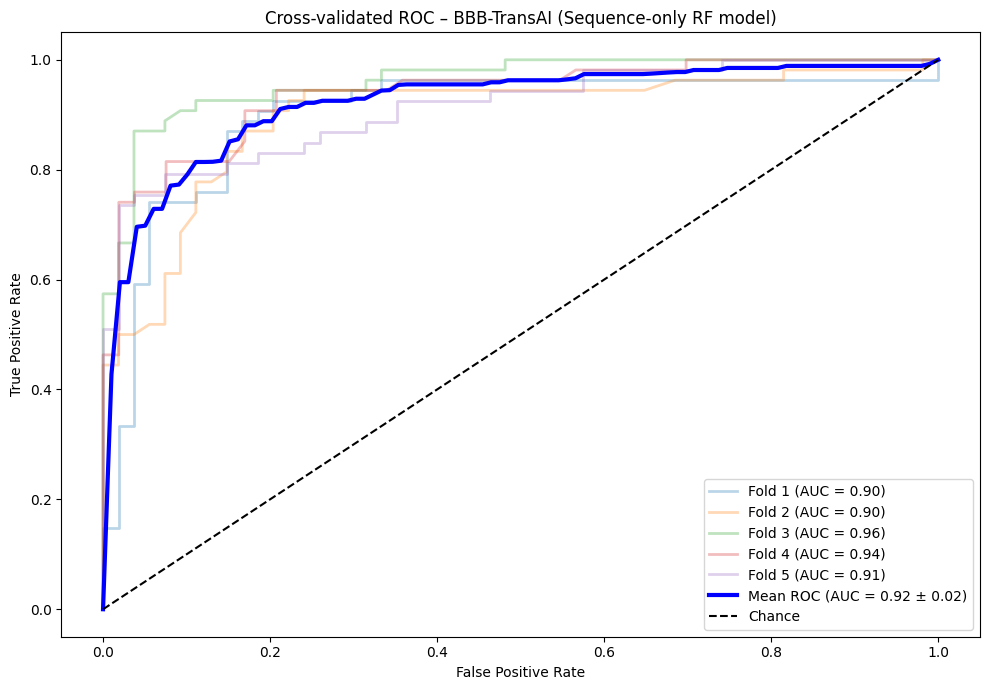

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import joblib, json

# 1) Load features (1134 descriptors)
feat = pd.read_csv("../features/bbb_all_features_11desc.csv")   # or r"D:\BBB Trans AI\features\bbb_all_features_11desc.csv"

# 2) Load ID + labels from the original dataset
labels = pd.read_csv("../data/bbb_dataset.csv")                 # or r"D:\BBB Trans AI\data\bbb_dataset.csv"

# Keep only ID and BBB_label from labels file
labels = labels[["ID", "BBB_label"]]

# 3) Merge features + labels on ID
df = pd.merge(feat, labels, on="ID", how="inner")

print(df.shape)
print(df.columns[:10])   # quick sanity check

# 4) Load the list of sequence-only features (top-200 or top-208)
with open("../models/bbb_rf_top200_features.json", "r") as f:
    seq_features = json.load(f)

X = df[seq_features].values
y = df["BBB_label"].values

# 5) Load the trained sequence-only RF model
rf_seq = joblib.load("../models/bbb_rf_top200.pkl")

# 6) 5-fold cross-validated ROC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 7))

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    rf_seq.fit(X[train_idx], y[train_idx])
    probas = rf_seq.predict_proba(X[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y[test_idx], probas)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    plt.plot(fpr, tpr, lw=2, alpha=0.3,
             label=f"Fold {fold_idx} (AUC = {roc_auc:.2f})")

    # interpolate TPR on common FPR grid for mean curve
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

# Mean ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color="blue",
         label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})",
         lw=3)

# Chance line
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Chance")

plt.title("Cross-validated ROC – BBB-TransAI (Sequence-only RF model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(False)
plt.tight_layout()

plt.savefig("roc_sequence_only_model.png", dpi=300, bbox_inches="tight")
plt.show()
